# 04D — Post-election temporal adaptation validation

04C 的整体 Validation Macro-F1 达到 `0.723`，但 2024 年英国大选后的分组表现明显下降。本 Notebook 不再混合大选前后数据，而是进行严格的时间回测。

流程：

1. 审计大选前后的执政党、主要反对党和 `party_role` 映射；
2. 将 2024 年大选后 division 按时间分成前半段和后半段；
3. 使用前半段作为新政治环境的 adaptation 数据；
4. 使用后半段作为 temporal holdout；
5. 固定使用 04C 的 `hybrid_global_party_extended` 架构和 `0.50` 阈值；
6. 比较不适应、加入大选前数据、加入早期大选后数据三种情景；
7. 默认不运行 2025–2026 Test。

该设计回答的是：模型看到少量 Labour 执政时期数据后，能否预测更晚的大选后投票。

In [1]:
# 导入本 Notebook 需要的库。
from pathlib import Path
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import hstack
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
TARGET = 'target_binary_support'
TEXT_COLUMN = 'model_text'
ELECTION_TRANSITION_DATE = pd.Timestamp('2024-07-05')

# 第一次运行必须保持 False；通过时间校验后才能运行最终 Test。
RUN_FINAL_TEST = False

# 时间校验使用独立标准，不用大选前的高分掩盖大选后问题。
MIN_TEMPORAL_MACRO_F1 = 0.65
MIN_TEMPORAL_WORST_PARTY_MACRO_F1 = 0.55
MIN_TEMPORAL_ROWS_PER_PARTY = 15

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'processed' / 'model_v2'
OUTPUT_DIR = DATA_DIR / 'temporal_adaptation'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / 'model_train_v2.csv'
VALIDATION_PATH = DATA_DIR / 'model_validation_v2.csv'
TEST_PATH = DATA_DIR / 'model_test_v2.csv'

print('Election transition:', ELECTION_TRANSITION_DATE.date())
print('RUN_FINAL_TEST:', RUN_FINAL_TEST)

Election transition: 2024-07-05
RUN_FINAL_TEST: False


## 1. Load data and verify split safety

Test 只用于检查主键和 division 是否与开发数据重叠。开关关闭时不会显示 Test 标签分布或生成预测。

In [2]:
# 读取数据并统一基础类型。
historical_train = pd.read_csv(TRAIN_PATH).reset_index(drop=True)
validation_2024 = pd.read_csv(VALIDATION_PATH).reset_index(drop=True)
test = pd.read_csv(TEST_PATH).reset_index(drop=True)

for frame in (historical_train, validation_2024, test):
    frame[TARGET] = frame[TARGET].astype(int)
    frame[TEXT_COLUMN] = frame[TEXT_COLUMN].fillna('').astype(str)
    frame['motion_date'] = pd.to_datetime(frame['motion_date'])

# 防止同一个议案跨原始 Train、Validation 和 Test。
assert historical_train['row_id'].is_unique
assert validation_2024['row_id'].is_unique
assert test['row_id'].is_unique
assert not set(historical_train['division_key']) & set(validation_2024['division_key'])
assert not set(historical_train['division_key']) & set(test['division_key'])
assert not set(validation_2024['division_key']) & set(test['division_key'])

development_overview = pd.DataFrame({
    'rows': [len(historical_train), len(validation_2024)],
    'divisions': [
        historical_train['division_key'].nunique(),
        validation_2024['division_key'].nunique(),
    ],
    'support_rate': [
        historical_train[TARGET].mean(),
        validation_2024[TARGET].mean(),
    ],
    'start_date': [
        historical_train['motion_date'].min(),
        validation_2024['motion_date'].min(),
    ],
    'end_date': [
        historical_train['motion_date'].max(),
        validation_2024['motion_date'].max(),
    ],
}, index=['historical_train', 'validation_2024'])
display(development_overview.round(3))

,rows,divisions,support_rate,start_date,end_date
historical_train,2822,770,0.569,2016-01-06,2023-12-13
validation_2024,570,169,0.591,2024-01-09,2024-12-17


## 2. Audit the 2024 government-role transition

预期映射：

- 2024-07-05 之前：Conservative 为执政党，Labour 为主要反对党；
- 2024-07-05 及之后：Labour 为执政党，Conservative 为主要反对党；
- Green 和 Liberal Democrat 保持较小反对党。

如果这里失败，应先修复数据映射，而不是继续建模。

In [3]:
def normalise_label(series):
    # 统一字符串格式，减少大小写和空格造成的假错误。
    return (
        series.fillna('unknown')
        .astype(str)
        .str.strip()
        .str.lower()
    )


role_audit = validation_2024[[
    'row_id', 'division_key', 'motion_date', 'party',
    'government_party', 'main_opposition_party', 'party_role',
]].copy()

role_audit['party_norm'] = normalise_label(role_audit['party'])
role_audit['government_party_norm'] = normalise_label(
    role_audit['government_party']
)
role_audit['main_opposition_party_norm'] = normalise_label(
    role_audit['main_opposition_party']
)
role_audit['party_role_norm'] = normalise_label(role_audit['party_role'])
role_audit['period'] = np.where(
    role_audit['motion_date'] < ELECTION_TRANSITION_DATE,
    'pre_2024_election',
    'post_2024_election',
)

role_audit['expected_government_party'] = np.where(
    role_audit['motion_date'] < ELECTION_TRANSITION_DATE,
    'conservative',
    'labour',
)
role_audit['expected_main_opposition_party'] = np.where(
    role_audit['motion_date'] < ELECTION_TRANSITION_DATE,
    'labour',
    'conservative',
)

def expected_role(row):
    # 根据日期和政党生成预期角色。
    if row['party_norm'] == row['expected_government_party']:
        return 'governing_party'
    if row['party_norm'] == row['expected_main_opposition_party']:
        return 'main_opposition'
    return 'smaller_opposition'


role_audit['expected_party_role'] = role_audit.apply(expected_role, axis=1)
role_audit['government_party_ok'] = role_audit[
    'government_party_norm'
].eq(role_audit['expected_government_party'])
role_audit['main_opposition_ok'] = role_audit[
    'main_opposition_party_norm'
].eq(role_audit['expected_main_opposition_party'])
role_audit['party_role_ok'] = role_audit[
    'party_role_norm'
].eq(role_audit['expected_party_role'])

mapping_summary = role_audit.groupby('period')[[
    'government_party_ok', 'main_opposition_ok', 'party_role_ok'
]].agg(['count', 'mean'])
display(mapping_summary.round(3))

mapping_errors = role_audit[
    ~(
        role_audit['government_party_ok']
        & role_audit['main_opposition_ok']
        & role_audit['party_role_ok']
    )
]
display(mapping_errors.head(20))

assert len(mapping_errors) == 0, (
    '2024 政党角色映射存在错误。请把 mapping_errors 输出发回，不要继续建模。'
)

government_party_ok      main_opposition_ok      party_role_ok     
                                 count mean              count mean         count mean
period                                                                                
post_2024_election                 214  1.0                214  1.0           214  1.0
pre_2024_election                  356  1.0                356  1.0           356  1.0

,row_id,division_key,motion_date,party,government_party,main_opposition_party,party_role,party_norm,government_party_norm,main_opposition_party_norm,party_role_norm,period,expected_government_party,expected_main_opposition_party,expected_party_role,government_party_ok,main_opposition_ok,party_role_ok


## 3. Create chronological adaptation and temporal holdout sets

大选后的唯一 division 按日期排序。前一半作为 adaptation，后一半作为 temporal holdout。这样不依赖固定月份，并保证两个阶段拥有接近的议案数量。

同一个 division 的四个政党记录始终留在同一阶段。

In [4]:
# 大选前数据可以在预测新政府时期之前正常获得。
pre_election_2024 = validation_2024[
    validation_2024['motion_date'] < ELECTION_TRANSITION_DATE
].copy()
post_election_2024 = validation_2024[
    validation_2024['motion_date'] >= ELECTION_TRANSITION_DATE
].copy()

# 按 division 的最早日期排序，然后进行严格的前后切分。
post_divisions = (
    post_election_2024.groupby('division_key', as_index=False)['motion_date']
    .min()
    .sort_values(['motion_date', 'division_key'])
    .reset_index(drop=True)
)

assert len(post_divisions) >= 20, '大选后 division 太少，无法进行时间回测。'
adaptation_division_count = len(post_divisions) // 2
adaptation_keys = set(
    post_divisions.iloc[:adaptation_division_count]['division_key']
)
holdout_keys = set(
    post_divisions.iloc[adaptation_division_count:]['division_key']
)

adaptation_2024 = post_election_2024[
    post_election_2024['division_key'].isin(adaptation_keys)
].copy()
temporal_holdout = post_election_2024[
    post_election_2024['division_key'].isin(holdout_keys)
].copy()

assert not adaptation_keys & holdout_keys
assert adaptation_2024['motion_date'].max() <= temporal_holdout['motion_date'].min()

temporal_split_overview = pd.DataFrame({
    'rows': [
        len(historical_train),
        len(pre_election_2024),
        len(adaptation_2024),
        len(temporal_holdout),
    ],
    'divisions': [
        historical_train['division_key'].nunique(),
        pre_election_2024['division_key'].nunique(),
        adaptation_2024['division_key'].nunique(),
        temporal_holdout['division_key'].nunique(),
    ],
    'start_date': [
        historical_train['motion_date'].min(),
        pre_election_2024['motion_date'].min(),
        adaptation_2024['motion_date'].min(),
        temporal_holdout['motion_date'].min(),
    ],
    'end_date': [
        historical_train['motion_date'].max(),
        pre_election_2024['motion_date'].max(),
        adaptation_2024['motion_date'].max(),
        temporal_holdout['motion_date'].max(),
    ],
    'support_rate': [
        historical_train[TARGET].mean(),
        pre_election_2024[TARGET].mean(),
        adaptation_2024[TARGET].mean(),
        temporal_holdout[TARGET].mean(),
    ],
}, index=[
    'historical_train',
    'pre_election_2024',
    'adaptation_2024',
    'temporal_holdout',
])
display(temporal_split_overview.round(3))

holdout_party_counts = temporal_holdout.groupby('party').size()
assert holdout_party_counts.min() >= MIN_TEMPORAL_ROWS_PER_PARTY, (
    'Temporal holdout 某个政党的行数不足，结果会过于不稳定。'
)
display(holdout_party_counts.rename('holdout_rows').to_frame())

,rows,divisions,start_date,end_date,support_rate
historical_train,2822,770,2016-01-06,2023-12-13,0.569
pre_election_2024,356,106,2024-01-09,2024-05-24,0.607
adaptation_2024,100,31,2024-07-22,2024-11-06,0.590
temporal_holdout,114,32,2024-11-06,2024-12-17,0.544


,holdout_rows
party,
conservative,29
green,28
labour,32
liberal-democrat,25


## 4. Audit distribution shift

这里比较大选前、adaptation 和 temporal holdout 的标签、政府背书覆盖、motion type 与 policy domain。它用于判断表现变化来自政党角色，还是议案构成也发生了变化。

In [5]:
# 为三个 2024 阶段添加可读标签。
audit_2024 = pd.concat([
    pre_election_2024.assign(temporal_stage='pre_election'),
    adaptation_2024.assign(temporal_stage='adaptation'),
    temporal_holdout.assign(temporal_stage='temporal_holdout'),
], ignore_index=True)

party_stage_distribution = (
    audit_2024.groupby(['temporal_stage', 'party'])[TARGET]
    .agg(rows='size', support_rate='mean')
    .reset_index()
)
display(party_stage_distribution.round(3))

backing_stage_distribution = (
    audit_2024.groupby('temporal_stage')
    .agg(
        rows=('row_id', 'size'),
        government_backing_known_rate=('government_backing_known', 'mean'),
        government_backed_rate=('final_object_government_backed', 'mean'),
    )
)
display(backing_stage_distribution.round(3))

motion_type_distribution = pd.crosstab(
    audit_2024['motion_type'],
    audit_2024['temporal_stage'],
    normalize='columns',
).sort_values('temporal_holdout', ascending=False)
display(motion_type_distribution.head(15).round(3))

domain_distribution = pd.crosstab(
    audit_2024['policy_domain_primary'],
    audit_2024['temporal_stage'],
    normalize='columns',
).sort_values('temporal_holdout', ascending=False)
display(domain_distribution.head(15).round(3))

,temporal_stage,party,rows,support_rate
0,adaptation,conservative,25,0.320
1,adaptation,green,28,0.786
2,adaptation,labour,31,0.516
3,adaptation,liberal-democrat,16,0.812
4,pre_election,conservative,105,0.352
5,pre_election,green,79,0.696
6,pre_election,labour,88,0.705
7,pre_election,liberal-democrat,84,0.738
8,temporal_holdout,conservative,29,0.414
9,temporal_holdout,green,28,0.607


,rows,government_backing_known_rate,government_backed_rate
temporal_stage,,,
adaptation,100,0.620,0.597
pre_election,356,0.742,0.591
temporal_holdout,114,0.693,0.481


temporal_stage,adaptation,pre_election,temporal_holdout
motion_type,,,
proposed_clause,0.00,0.213,0.298
second_stage,0.09,0.045,0.175
amendment,0.40,0.129,0.096
approve_statutory_instrument,0.03,0.076,0.096
committee_clause,0.00,0.031,0.070
third_stage,0.03,0.039,0.070
lords_amendment,0.00,0.303,0.061
other,0.21,0.051,0.053
bill_introduction,0.00,0.028,0.035


temporal_stage,adaptation,pre_election,temporal_holdout
policy_domain_primary,,,
economy_finance_business,0.37,0.247,0.439
other_or_unclear,0.07,0.087,0.167
constitution_democracy_devolution,0.00,0.059,0.132
employment_labour,0.03,0.020,0.079
transport_infrastructure,0.11,0.008,0.061
education_skills_children,0.07,0.011,0.035
health_social_care,0.03,0.020,0.035
housing_planning_local_government,0.00,0.070,0.035
welfare_pensions_poverty,0.08,0.000,0.018


## 5. Recreate the frozen 04C hybrid architecture

本 Notebook 不重新搜索架构。固定使用：

```text
global Word TF-IDF
+ party-specific Word TF-IDF interaction blocks
+ shared extended institutional features
+ Logistic Regression (C=0.5, threshold=0.50)
```

这样时间校验只测试“加入早期新环境数据是否有效”，不会因为反复调模型而污染 temporal holdout。

In [6]:
# 延续 04C 的共享扩展特征。
EXTENDED_CATEGORICAL = [
    'party',
    'party_role',
    'government_backing_status',
    'role_backing_interaction',
    'party_object_alignment',
    'motion_type',
    'motion_family',
    'policy_domain_primary',
    'policy_domain_confidence',
    'government_party',
    'main_opposition_party',
]

EXTENDED_NUMERIC = [
    'government_backing_known',
    'final_object_government_backed',
    'is_governing_party',
    'is_main_opposition',
    'is_opposition_day',
    'motion_year',
    'motion_month',
    'years_since_2016',
    'total_possible_members',
    'has_legislation_name',
    'bill_link_available',
    'is_amendment',
    'is_new_clause',
    'is_financial_motion',
    'legacy_domain_count',
    'policy_domain_count',
    'is_econ_finance',
    'is_justice_security',
    'is_env_infra',
    'is_social_health',
    'is_national_affairs',
]


def add_model_features(frame):
    # 根据政府背书是否已知，构造稳定的三档类别。
    result = frame.copy()
    known = result['government_backing_known'].fillna(0).astype(int).eq(1)
    backed = result['final_object_government_backed'].fillna(0).astype(int).eq(1)
    result['government_backing_status'] = np.select(
        [~known, backed],
        ['unknown', 'government_backed'],
        default='not_government_backed',
    )
    result['role_backing_interaction'] = (
        result['party_role'].fillna('unknown').astype(str)
        + '__'
        + result['government_backing_status'].astype(str)
    )
    return result


historical_train = add_model_features(historical_train)
pre_election_2024 = add_model_features(pre_election_2024)
adaptation_2024 = add_model_features(adaptation_2024)
temporal_holdout = add_model_features(temporal_holdout)
test = add_model_features(test)

required_features = {
    TEXT_COLUMN,
    *EXTENDED_CATEGORICAL,
    *EXTENDED_NUMERIC,
}
missing_features = required_features - set(historical_train.columns)
assert not missing_features, f'Missing features: {sorted(missing_features)}'

In [7]:
def make_word_vectorizer():
    # 使用 04C 已冻结的 Word TF-IDF 参数。
    return TfidfVectorizer(
        lowercase=True,
        strip_accents='unicode',
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.98,
        max_features=30000,
        sublinear_tf=True,
    )


def make_structured_transformer():
    # 类别特征 one-hot，数值特征补缺并缩放。
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('one_hot', OneHotEncoder(handle_unknown='ignore')),
    ])
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', StandardScaler(with_mean=False)),
    ])
    return ColumnTransformer([
        ('categorical', categorical_pipeline, EXTENDED_CATEGORICAL),
        ('numeric', numeric_pipeline, EXTENDED_NUMERIC),
    ], remainder='drop')


def make_party_text_blocks(text_matrix, parties, party_order):
    # 每条记录只激活当前政党的文本区块。
    party_values = pd.Series(parties).astype(str).to_numpy()
    blocks = []
    for party in party_order:
        mask = (party_values == party).astype(float).reshape(-1, 1)
        blocks.append(text_matrix.multiply(mask))
    return hstack(blocks, format='csr')


def fit_feature_bundle(development_frame, evaluation_frame):
    # 词表只根据当前情景的 development 数据拟合。
    unique_development_text = (
        development_frame.drop_duplicates('division_key')[TEXT_COLUMN]
        .fillna('')
        .astype(str)
    )
    party_order = sorted(development_frame['party'].astype(str).unique())

    word_vectorizer = make_word_vectorizer()
    word_vectorizer.fit(unique_development_text)
    development_word = word_vectorizer.transform(
        development_frame[TEXT_COLUMN]
    )
    evaluation_word = word_vectorizer.transform(
        evaluation_frame[TEXT_COLUMN]
    )

    development_party_text = make_party_text_blocks(
        development_word,
        development_frame['party'],
        party_order,
    )
    evaluation_party_text = make_party_text_blocks(
        evaluation_word,
        evaluation_frame['party'],
        party_order,
    )

    structured_transformer = make_structured_transformer()
    development_structured = structured_transformer.fit_transform(
        development_frame
    )
    evaluation_structured = structured_transformer.transform(
        evaluation_frame
    )

    # 固定为 04C 胜出的 global + party interaction + extended 结构。
    development_matrix = hstack([
        development_word,
        development_party_text,
        development_structured,
    ], format='csr')
    evaluation_matrix = hstack([
        evaluation_word,
        evaluation_party_text,
        evaluation_structured,
    ], format='csr')

    fitted_features = {
        'word': word_vectorizer,
        'structured': structured_transformer,
        'party_order': party_order,
    }
    return development_matrix, evaluation_matrix, fitted_features


def make_classifier():
    # 保持 04C 的正则化和类别权重不变。
    return LogisticRegression(
        solver='liblinear',
        penalty='l2',
        C=0.5,
        class_weight='balanced',
        max_iter=2500,
        random_state=RANDOM_STATE,
    )

## 6. Evaluation helpers

时间验证固定使用 `threshold=0.50`。不在 temporal holdout 上重新选择阈值，否则会高估未来表现。

In [8]:
def safe_roc_auc(y_true, probabilities):
    # 只有一个真实类别时 ROC-AUC 无定义。
    return (
        roc_auc_score(y_true, probabilities)
        if pd.Series(y_true).nunique() == 2
        else np.nan
    )


def evaluate_probabilities(y_true, probabilities, threshold=0.50):
    # 同时评价分类结果和概率质量。
    probabilities = np.asarray(probabilities)
    predictions = (probabilities >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(y_true, predictions),
        'balanced_accuracy': balanced_accuracy_score(y_true, predictions),
        'macro_f1': f1_score(
            y_true, predictions, average='macro', zero_division=0
        ),
        'support_precision': precision_score(
            y_true, predictions, zero_division=0
        ),
        'support_recall': recall_score(y_true, predictions, zero_division=0),
        'support_f1': f1_score(y_true, predictions, zero_division=0),
        'roc_auc': safe_roc_auc(y_true, probabilities),
        'log_loss': log_loss(y_true, probabilities, labels=[0, 1]),
        'brier': brier_score_loss(y_true, probabilities),
        'threshold': threshold,
    }


def subgroup_metrics(frame, probabilities, threshold=0.50):
    # 分政党检查，避免整体分数掩盖单一政党失败。
    work = frame[['party', TARGET]].copy()
    work['probability'] = np.asarray(probabilities)
    work['prediction'] = work['probability'].ge(threshold).astype(int)
    rows = []
    for party, subset in work.groupby('party'):
        rows.append({
            'party': party,
            'rows': len(subset),
            'support_rate': subset[TARGET].mean(),
            'predicted_support_rate': subset['prediction'].mean(),
            'mean_probability': subset['probability'].mean(),
            'accuracy': accuracy_score(subset[TARGET], subset['prediction']),
            'balanced_accuracy': (
                balanced_accuracy_score(subset[TARGET], subset['prediction'])
                if subset[TARGET].nunique() == 2 else np.nan
            ),
            'macro_f1': (
                f1_score(
                    subset[TARGET], subset['prediction'],
                    average='macro', zero_division=0,
                )
                if subset[TARGET].nunique() == 2 else np.nan
            ),
        })
    return pd.DataFrame(rows).sort_values('macro_f1', na_position='last')


def division_bootstrap_macro_f1(
    frame,
    probabilities,
    threshold=0.50,
    iterations=1000,
):
    # 以 division 为单位重采样，保留同一议案内政党结果的相关性。
    rng = np.random.default_rng(RANDOM_STATE)
    division_to_indices = {
        key: np.flatnonzero(frame['division_key'].to_numpy() == key)
        for key in frame['division_key'].unique()
    }
    division_keys = np.array(list(division_to_indices), dtype=object)
    y_true = frame[TARGET].to_numpy()
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    scores = []

    for _ in range(iterations):
        sampled_keys = rng.choice(
            division_keys, size=len(division_keys), replace=True
        )
        sampled_indices = np.concatenate([
            division_to_indices[key] for key in sampled_keys
        ])
        scores.append(f1_score(
            y_true[sampled_indices],
            predictions[sampled_indices],
            average='macro',
            zero_division=0,
        ))

    return {
        'bootstrap_mean': float(np.mean(scores)),
        'ci_2_5': float(np.quantile(scores, 0.025)),
        'ci_97_5': float(np.quantile(scores, 0.975)),
    }

## 7. Compare temporal adaptation scenarios

三种主要情景：

- `historical_only`：只使用 2016–2023；
- `historical_plus_pre_election`：再加入 2024 大选前数据；
- `adapted_unweighted`：再加入大选后早期 adaptation 数据。

另提供一个 `adapted_recent_weighted` 诊断，把 adaptation 行权重设为 2。它只用于观察近期加权是否值得以后研究，不作为本轮验收模型。

In [9]:
# 构造严格按时间递增的开发情景。
development_pre = pd.concat(
    [historical_train, pre_election_2024], ignore_index=True
)
development_adapted = pd.concat(
    [historical_train, pre_election_2024, adaptation_2024],
    ignore_index=True,
)

scenarios = {
    'historical_only': {
        'development': historical_train,
        'sample_weight': None,
    },
    'historical_plus_pre_election': {
        'development': development_pre,
        'sample_weight': None,
    },
    'adapted_unweighted': {
        'development': development_adapted,
        'sample_weight': None,
    },
}

# 近期加权只作为诊断，不用于验收或自动选择。
recent_weights = np.ones(len(development_adapted), dtype=float)
recent_weights[
    development_adapted['row_id'].isin(adaptation_2024['row_id'])
] = 2.0
scenarios['adapted_recent_weighted'] = {
    'development': development_adapted,
    'sample_weight': recent_weights,
}

scenario_rows = []
scenario_probabilities = {}
scenario_models = {}

for scenario_name, specification in scenarios.items():
    development_frame = specification['development']
    sample_weight = specification['sample_weight']

    started = time.perf_counter()
    development_matrix, holdout_matrix, fitted_features = fit_feature_bundle(
        development_frame,
        temporal_holdout,
    )
    classifier = make_classifier()
    classifier.fit(
        development_matrix,
        development_frame[TARGET].to_numpy(),
        sample_weight=sample_weight,
    )
    positive_index = list(classifier.classes_).index(1)
    probabilities = classifier.predict_proba(
        holdout_matrix
    )[:, positive_index]
    fit_seconds = time.perf_counter() - started

    metrics = evaluate_probabilities(
        temporal_holdout[TARGET].to_numpy(), probabilities, threshold=0.50
    )
    metrics.update({
        'scenario': scenario_name,
        'development_rows': len(development_frame),
        'development_divisions': development_frame['division_key'].nunique(),
        'fit_seconds': fit_seconds,
    })
    scenario_rows.append(metrics)
    scenario_probabilities[scenario_name] = probabilities
    scenario_models[scenario_name] = classifier

    print(
        f'{scenario_name}: macro_f1={metrics["macro_f1"]:.3f}, '
        f'roc_auc={metrics["roc_auc"]:.3f}, fit={fit_seconds:.2f}s'
    )

scenario_comparison = (
    pd.DataFrame(scenario_rows)
    .set_index('scenario')
    .sort_values('macro_f1', ascending=False)
)
scenario_comparison.to_csv(
    OUTPUT_DIR / 'temporal_scenario_comparison.csv'
)
display(scenario_comparison.round(3))

historical_only: macro_f1=0.395, roc_auc=0.368, fit=0.54s
historical_plus_pre_election: macro_f1=0.430, roc_auc=0.428, fit=0.65s
adapted_unweighted: macro_f1=0.482, roc_auc=0.454, fit=0.68s
adapted_recent_weighted: macro_f1=0.515, roc_auc=0.469, fit=0.70s


,accuracy,balanced_accuracy,macro_f1,support_precision,support_recall,support_f1,roc_auc,log_loss,brier,threshold,development_rows,development_divisions,fit_seconds
scenario,,,,,,,,,,,,,
adapted_recent_weighted,0.518,0.515,0.515,0.557,0.548,0.553,0.469,0.983,0.331,0.5,3278,907,0.703
adapted_unweighted,0.482,0.484,0.482,0.527,0.468,0.496,0.454,0.987,0.336,0.5,3278,907,0.675
historical_plus_pre_election,0.430,0.434,0.430,0.471,0.387,0.425,0.428,1.037,0.354,0.5,3178,876,0.648
historical_only,0.395,0.397,0.395,0.434,0.371,0.400,0.368,1.083,0.384,0.5,2822,770,0.543


## 8. Evaluate the predefined primary adaptation model

验收对象固定为 `adapted_unweighted`，不会因为 weighted 诊断偶然更高而临时换模型。

In [10]:
primary_scenario = 'adapted_unweighted'
primary_probabilities = scenario_probabilities[primary_scenario]
primary_metrics = evaluate_probabilities(
    temporal_holdout[TARGET].to_numpy(),
    primary_probabilities,
    threshold=0.50,
)
primary_party_metrics = subgroup_metrics(
    temporal_holdout,
    primary_probabilities,
    threshold=0.50,
)
bootstrap_interval = division_bootstrap_macro_f1(
    temporal_holdout,
    primary_probabilities,
    threshold=0.50,
    iterations=1000,
)

worst_party_macro_f1 = float(
    primary_party_metrics['macro_f1'].dropna().min()
)
minimum_party_rows = int(primary_party_metrics['rows'].min())

temporal_acceptance_checks = {
    'temporal_macro_f1_gate': (
        primary_metrics['macro_f1'] >= MIN_TEMPORAL_MACRO_F1
    ),
    'temporal_worst_party_gate': (
        worst_party_macro_f1 >= MIN_TEMPORAL_WORST_PARTY_MACRO_F1
    ),
    'minimum_party_rows_gate': (
        minimum_party_rows >= MIN_TEMPORAL_ROWS_PER_PARTY
    ),
}
temporal_validation_passes = all(temporal_acceptance_checks.values())

if temporal_validation_passes:
    next_step = (
        'Temporal validation passes. Freeze the pipeline, then enable the '
        'single final Test run.'
    )
else:
    next_step = (
        'Temporal validation does not pass. Do not run Test; inspect the '
        'holdout errors and distribution shift first.'
    )

primary_party_metrics.to_csv(
    OUTPUT_DIR / 'temporal_primary_party_metrics.csv', index=False
)

display(pd.Series({
    'primary_scenario': primary_scenario,
    'temporal_macro_f1': primary_metrics['macro_f1'],
    'temporal_accuracy': primary_metrics['accuracy'],
    'temporal_roc_auc': primary_metrics['roc_auc'],
    'worst_party_macro_f1': worst_party_macro_f1,
    'bootstrap_ci_2_5': bootstrap_interval['ci_2_5'],
    'bootstrap_ci_97_5': bootstrap_interval['ci_97_5'],
    'passes_all_temporal_gates': temporal_validation_passes,
    'next_step': next_step,
}, name='value').to_frame())

display(primary_party_metrics.round(3))

,value
primary_scenario,adapted_unweighted
temporal_macro_f1,0.482097
temporal_accuracy,0.482456
temporal_roc_auc,0.454094
worst_party_macro_f1,0.210256
bootstrap_ci_2_5,0.356709
bootstrap_ci_97_5,0.599173
passes_all_temporal_gates,False
next_step,Temporal validation does not pass. Do not run ...


,party,rows,support_rate,predicted_support_rate,mean_probability,accuracy,balanced_accuracy,macro_f1
1,green,28,0.607,0.464,0.582,0.214,0.209,0.210
2,labour,32,0.531,0.469,0.520,0.500,0.502,0.500
0,conservative,29,0.414,0.552,0.489,0.586,0.598,0.586
3,liberal-democrat,25,0.640,0.440,0.548,0.640,0.670,0.638


## 9. Temporal diagnostics

除了分数，还要比较 adaptation 前后支持率是否变化，以及 temporal holdout 中具体是哪一类被错判。

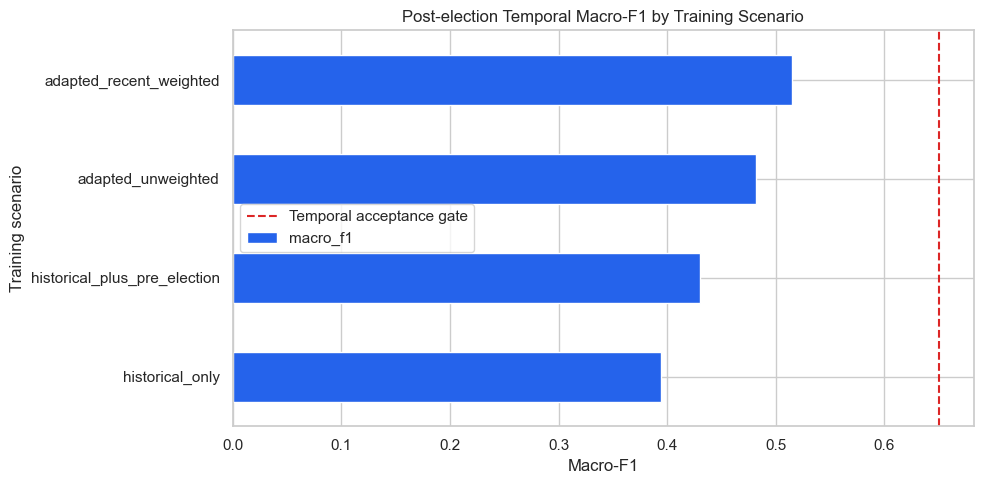

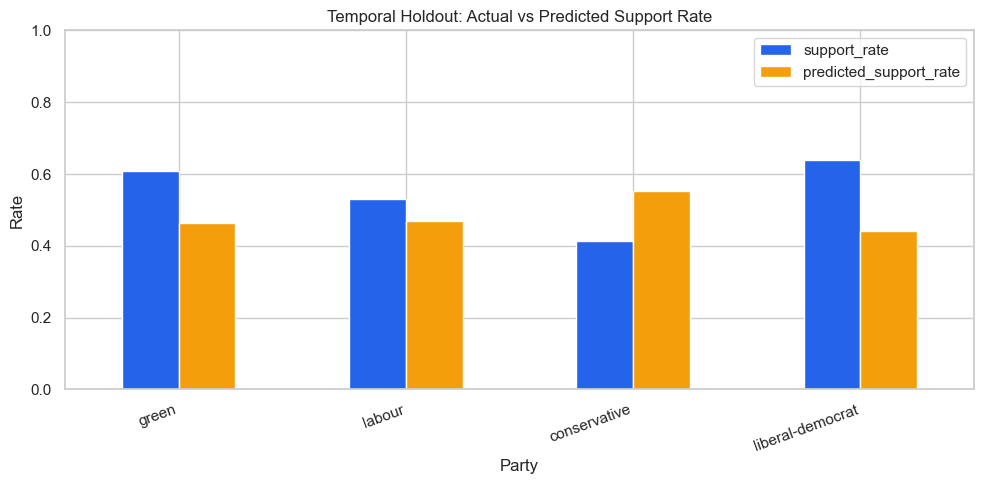

In [11]:
# 对比不同训练情景在同一个 temporal holdout 上的 Macro-F1。
plot_data = scenario_comparison.sort_values('macro_f1')
ax = plot_data['macro_f1'].plot(
    kind='barh', figsize=(10, 5), color='#2563EB'
)
ax.axvline(
    MIN_TEMPORAL_MACRO_F1,
    color='#DC2626',
    linestyle='--',
    label='Temporal acceptance gate',
)
ax.set_title('Post-election Temporal Macro-F1 by Training Scenario')
ax.set_xlabel('Macro-F1')
ax.set_ylabel('Training scenario')
ax.legend()
plt.tight_layout()
plt.show()

# 比较 temporal holdout 的真实支持率和预测支持率。
rate_plot = primary_party_metrics.set_index('party')[
    ['support_rate', 'predicted_support_rate']
]
ax = rate_plot.plot(kind='bar', figsize=(10, 5), color=['#2563EB', '#F59E0B'])
ax.set_title('Temporal Holdout: Actual vs Predicted Support Rate')
ax.set_xlabel('Party')
ax.set_ylabel('Rate')
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

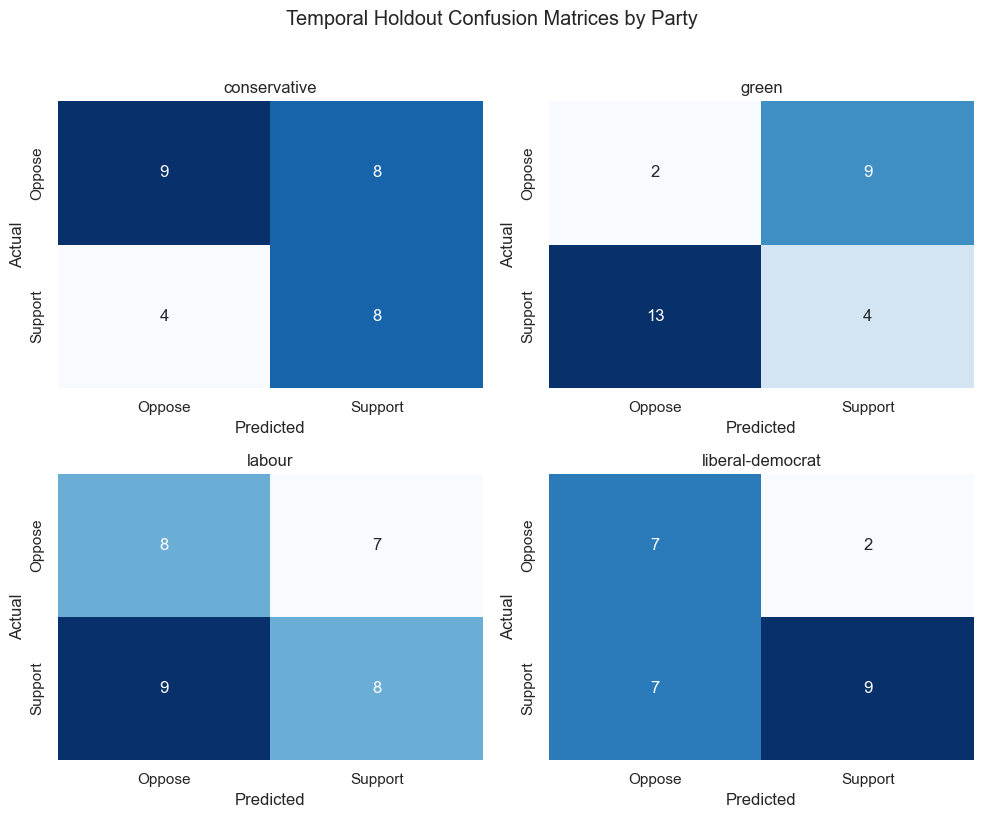

In [12]:
# 绘制 primary adaptation 模型的分政党混淆矩阵。
primary_predictions = (primary_probabilities >= 0.50).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, party in zip(axes.ravel(), sorted(temporal_holdout['party'].unique())):
    mask = temporal_holdout['party'].eq(party).to_numpy()
    matrix = confusion_matrix(
        temporal_holdout.loc[mask, TARGET],
        primary_predictions[mask],
        labels=[0, 1],
    )
    sns.heatmap(
        matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['Oppose', 'Support'],
        yticklabels=['Oppose', 'Support'],
        ax=ax,
    )
    ax.set_title(party)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Temporal Holdout Confusion Matrices by Party', y=1.02)
plt.tight_layout()
plt.show()

## 10. Save temporal holdout errors

输出只来自 2024 temporal holdout，不包含 Test。

In [13]:
# 保存逐行概率，便于后续定位错误议案。
temporal_predictions = temporal_holdout[[
    'row_id', 'division_key', 'motion_date', 'party',
    'motion_title_clean', 'motion_type', 'motion_family',
    'policy_domain_primary', 'party_role',
    'government_backing_known', 'final_object_government_backed', TARGET,
]].copy()
temporal_predictions['predicted_support_probability'] = primary_probabilities
temporal_predictions['predicted_label'] = primary_predictions
temporal_predictions['is_correct'] = temporal_predictions[
    'predicted_label'
].eq(temporal_predictions[TARGET])
temporal_predictions.to_csv(
    OUTPUT_DIR / 'temporal_holdout_predictions.csv', index=False
)

temporal_error_summary = (
    temporal_predictions[~temporal_predictions['is_correct']]
    .groupby(['party', 'motion_type', 'policy_domain_primary'], dropna=False)
    .size()
    .rename('errors')
    .reset_index()
    .sort_values('errors', ascending=False)
)
display(temporal_error_summary.head(25))

,party,motion_type,policy_domain_primary,errors
19,green,proposed_clause,economy_finance_business,4
28,labour,approve_statutory_instrument,economy_finance_business,2
15,green,committee_clause,economy_finance_business,2
30,labour,committee_clause,economy_finance_business,2
4,conservative,lords_amendment,transport_infrastructure,2
5,conservative,proposed_clause,constitution_democracy_devolution,2
31,labour,lords_amendment,transport_infrastructure,2
21,green,second_stage,economy_finance_business,2
39,liberal-democrat,approve_statutory_instrument,economy_finance_business,2
12,green,approve_statutory_instrument,economy_finance_business,2


## 11. Optional single final Test

只有 `adapted_unweighted` 通过全部时间 Gate 后，才能把 `RUN_FINAL_TEST=True`。最终模型会使用 2016–2024 全部可用数据重新训练，然后一次性评测 2025–2026 Test。

In [14]:
test_metrics = None
test_party_metrics = None

if RUN_FINAL_TEST:
    assert temporal_validation_passes, (
        '时间校验未通过，禁止运行最终 Test。'
    )

    # 时间验证通过后，使用截至 2024 年底的全部开发数据训练最终模型。
    final_development = pd.concat([
        historical_train,
        pre_election_2024,
        adaptation_2024,
        temporal_holdout,
    ], ignore_index=True)

    final_development_matrix, test_matrix, final_features = (
        fit_feature_bundle(final_development, test)
    )
    final_model = make_classifier()
    final_model.fit(
        final_development_matrix,
        final_development[TARGET].to_numpy(),
    )
    positive_index = list(final_model.classes_).index(1)
    test_probabilities = final_model.predict_proba(
        test_matrix
    )[:, positive_index]

    test_metrics = evaluate_probabilities(
        test[TARGET].to_numpy(), test_probabilities, threshold=0.50
    )
    test_party_metrics = subgroup_metrics(
        test, test_probabilities, threshold=0.50
    )

    test_predictions = test[[
        'row_id', 'division_key', 'motion_date', 'party',
        'motion_title_clean', TARGET,
    ]].copy()
    test_predictions['predicted_support_probability'] = test_probabilities
    test_predictions['predicted_label'] = (
        test_probabilities >= 0.50
    ).astype(int)
    test_predictions.to_csv(
        OUTPUT_DIR / 'final_test_predictions.csv', index=False
    )
    test_party_metrics.to_csv(
        OUTPUT_DIR / 'final_test_party_metrics.csv', index=False
    )

    display(pd.Series(test_metrics, name='test').to_frame())
    display(test_party_metrics.round(3))
else:
    print('Test was not run. Keep RUN_FINAL_TEST=False until temporal validation passes.')

Test was not run. Keep RUN_FINAL_TEST=False until temporal validation passes.


## 12. Summary for review

运行结束后，只需要把下面 Cell 的文本输出发回给我。

In [15]:
summary_lines = [
    '=== TEMPORAL VALIDATION SUMMARY FOR REVIEW ===',
    f'Election transition date: {ELECTION_TRANSITION_DATE.date()}',
    (
        'Adaptation period: '
        f'{adaptation_2024["motion_date"].min().date()} to '
        f'{adaptation_2024["motion_date"].max().date()}'
    ),
    (
        'Temporal holdout period: '
        f'{temporal_holdout["motion_date"].min().date()} to '
        f'{temporal_holdout["motion_date"].max().date()}'
    ),
    f'Adaptation divisions: {adaptation_2024["division_key"].nunique()}',
    f'Temporal holdout divisions: {temporal_holdout["division_key"].nunique()}',
    f'Primary scenario: {primary_scenario}',
    f'Temporal Macro-F1: {primary_metrics["macro_f1"]:.3f}',
    f'Temporal Accuracy: {primary_metrics["accuracy"]:.3f}',
    f'Temporal ROC-AUC: {primary_metrics["roc_auc"]:.3f}',
    f'Worst-party Macro-F1: {worst_party_macro_f1:.3f}',
    (
        'Division-bootstrap Macro-F1 95% CI: '
        f'[{bootstrap_interval["ci_2_5"]:.3f}, '
        f'{bootstrap_interval["ci_97_5"]:.3f}]'
    ),
    f'Temporal acceptance gates: {temporal_acceptance_checks}',
    f'Next step: {next_step}',
    'Scenario comparison:',
    scenario_comparison[['macro_f1', 'accuracy', 'roc_auc']]
    .round(3).to_string(),
    'Primary party metrics:',
    primary_party_metrics.round(3).to_string(index=False),
    f'RUN_FINAL_TEST: {RUN_FINAL_TEST}',
    (
        'Test result: NOT RUN'
        if test_metrics is None
        else f'Test Macro-F1: {test_metrics["macro_f1"]:.3f}'
    ),
    '=== END TEMPORAL VALIDATION SUMMARY ===',
]

summary_text = '\n'.join(summary_lines)
print(summary_text)

with open(OUTPUT_DIR / 'temporal_validation_summary.txt', 'w', encoding='utf-8') as file:
    file.write(summary_text)

=== TEMPORAL VALIDATION SUMMARY FOR REVIEW ===
Election transition date: 2024-07-05
Adaptation period: 2024-07-22 to 2024-11-06
Temporal holdout period: 2024-11-06 to 2024-12-17
Adaptation divisions: 31
Temporal holdout divisions: 32
Primary scenario: adapted_unweighted
Temporal Macro-F1: 0.482
Temporal Accuracy: 0.482
Temporal ROC-AUC: 0.454
Worst-party Macro-F1: 0.210
Division-bootstrap Macro-F1 95% CI: [0.357, 0.599]
Temporal acceptance gates: {'temporal_macro_f1_gate': False, 'temporal_worst_party_gate': False, 'minimum_party_rows_gate': True}
Next step: Temporal validation does not pass. Do not run Test; inspect the holdout errors and distribution shift first.
Scenario comparison:
                              macro_f1  accuracy  roc_auc
scenario                                                 
adapted_recent_weighted          0.515     0.518    0.469
adapted_unweighted               0.482     0.482    0.454
historical_plus_pre_election     0.430     0.430    0.428
historical_only